In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/kaggle/input/datasets/mattop/predict-students-dropout-and-academic-success/data.csv')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## MODULE 1

In [2]:
print(df.shape)
print(df['Target'].value_counts())
print(df.isnull().sum().sum())
print(df.info())

(4424, 37)
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualificatio

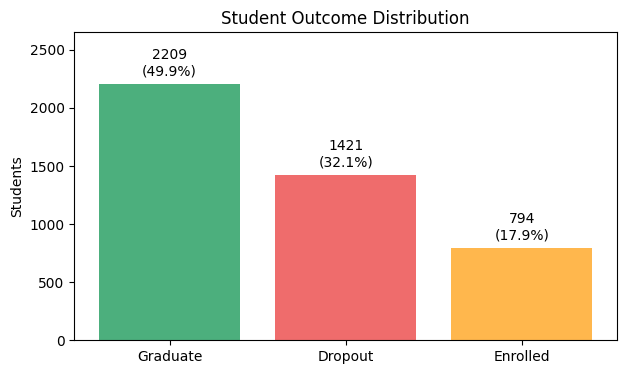

In [3]:
counts = df['Target'].value_counts()
pct = counts / len(df) * 100

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(counts.index, counts, color=['#4caf7d', '#ef6c6c', '#ffb74d'])

ax.bar_label(bars, labels=[f"{n}\n({p:.1f}%)" for n, p in zip(counts, pct)], padding=4)

ax.set(title="Student Outcome Distribution", ylabel="Students", ylim=(0, counts.max()*1.2))
plt.show()

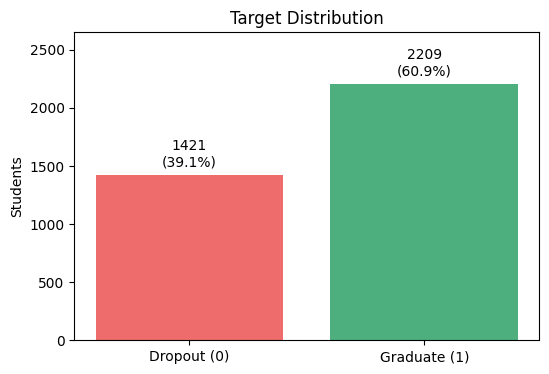

In [4]:
df = df[df['Target'] != 'Enrolled'].copy()

df['Target'] = df['Target'].map({'Dropout': 0, 'Graduate': 1})

counts = df['Target'].value_counts().sort_index()
pct = counts / len(df) * 100

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(['Dropout (0)', 'Graduate (1)'], counts, color=['#ef6c6c', '#4caf7d'])

ax.bar_label(bars, labels=[f'{n}\n({p:.1f}%)' for n, p in zip(counts, pct)], padding=4)

ax.set(title='Target Distribution', ylabel='Students', ylim=(0, counts.max()*1.2))
plt.show()

In [5]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
print("Shape:", df.shape)

Missing values: 0
Duplicates: 0
Shape: (3630, 37)


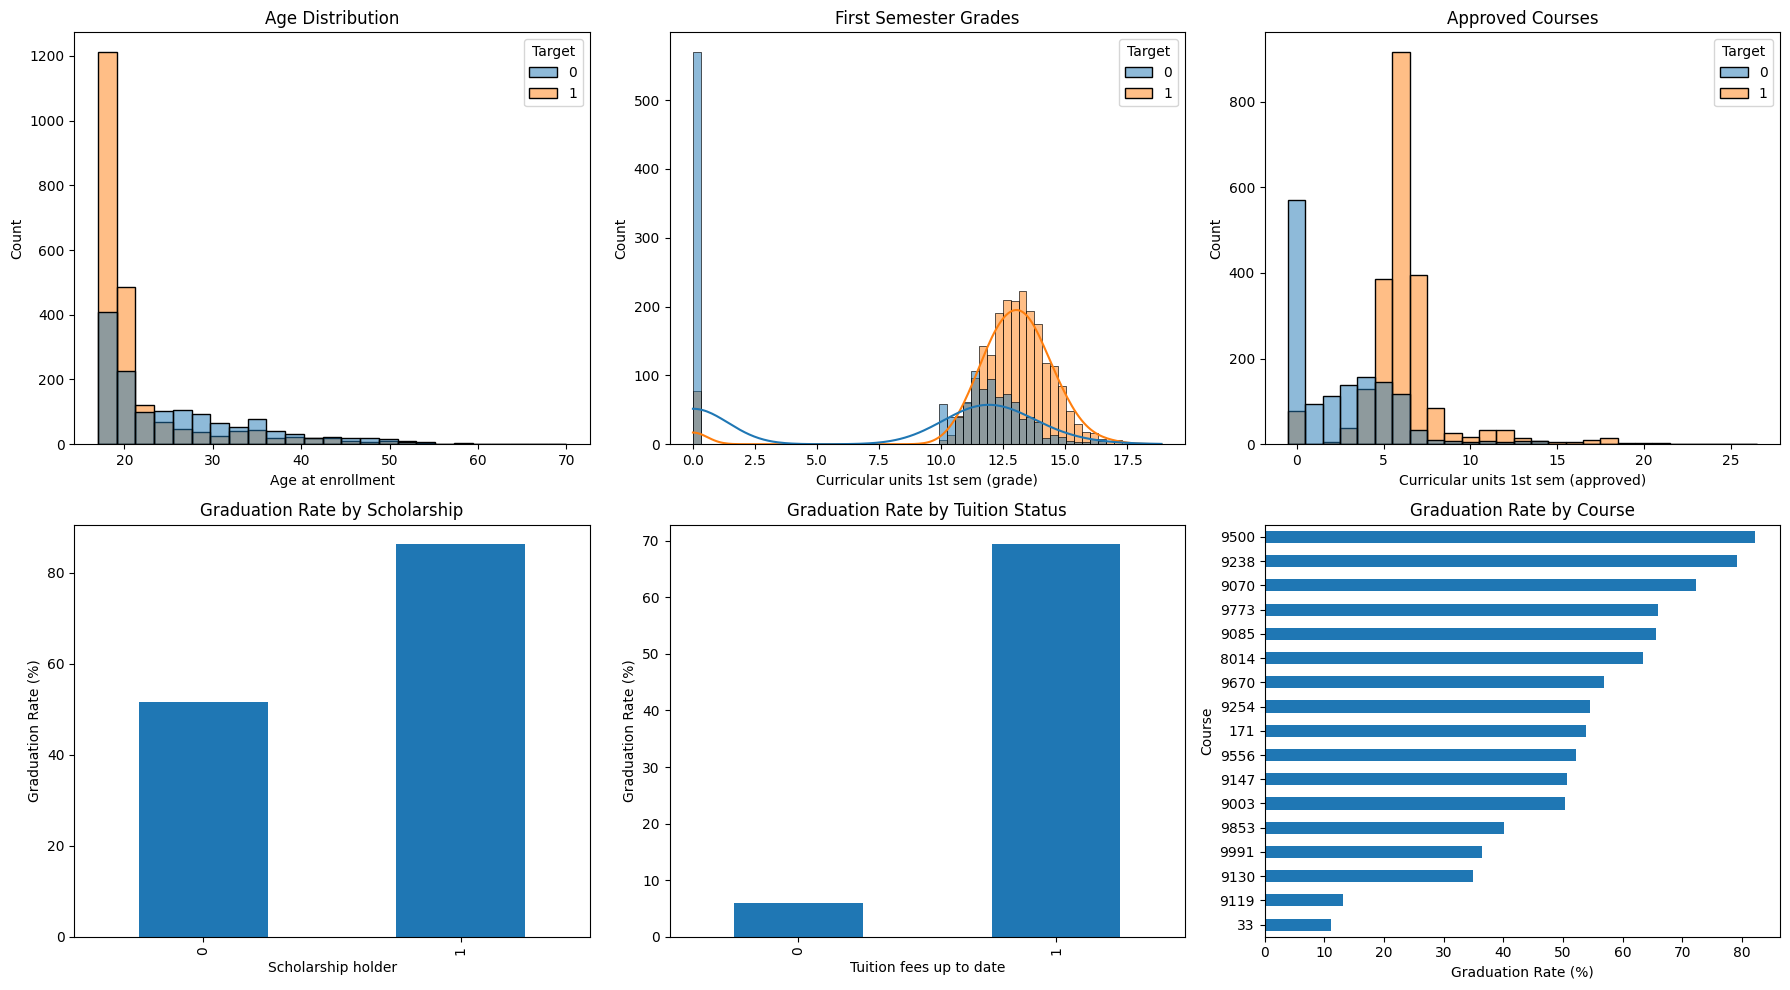

In [6]:
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

# 1. Age distribution
sns.histplot(data=df, x='Age at enrollment', hue='Target', bins=25, ax=ax[0, 0])
ax[0, 0].set_title('Age Distribution')

# 2. First semester grades
sns.histplot(data=df, x='Curricular units 1st sem (grade)', hue='Target', kde=True, ax=ax[0, 1])
ax[0, 1].set_title('First Semester Grades')

# 3. Approved courses
sns.histplot(data=df, x='Curricular units 1st sem (approved)', hue='Target', discrete=True, ax=ax[0, 2])
ax[0, 2].set_title('Approved Courses')

# 4. Graduation rate by scholarship
(df.groupby('Scholarship holder')['Target'].mean() * 100).plot.bar(ax=ax[1, 0])
ax[1, 0].set_title('Graduation Rate by Scholarship')
ax[1, 0].set_ylabel('Graduation Rate (%)')

# 5. Graduation rate by tuition status
(df.groupby('Tuition fees up to date')['Target'].mean() * 100).plot.bar(ax=ax[1, 1])
ax[1, 1].set_title('Graduation Rate by Tuition Status')
ax[1, 1].set_ylabel('Graduation Rate (%)')

# 6. Graduation rate by course
(df.groupby('Course')['Target'].mean() * 100).sort_values().plot.barh(ax=ax[1, 2])
ax[1, 2].set_title('Graduation Rate by Course')
ax[1, 2].set_xlabel('Graduation Rate (%)')

plt.tight_layout()
plt.show()

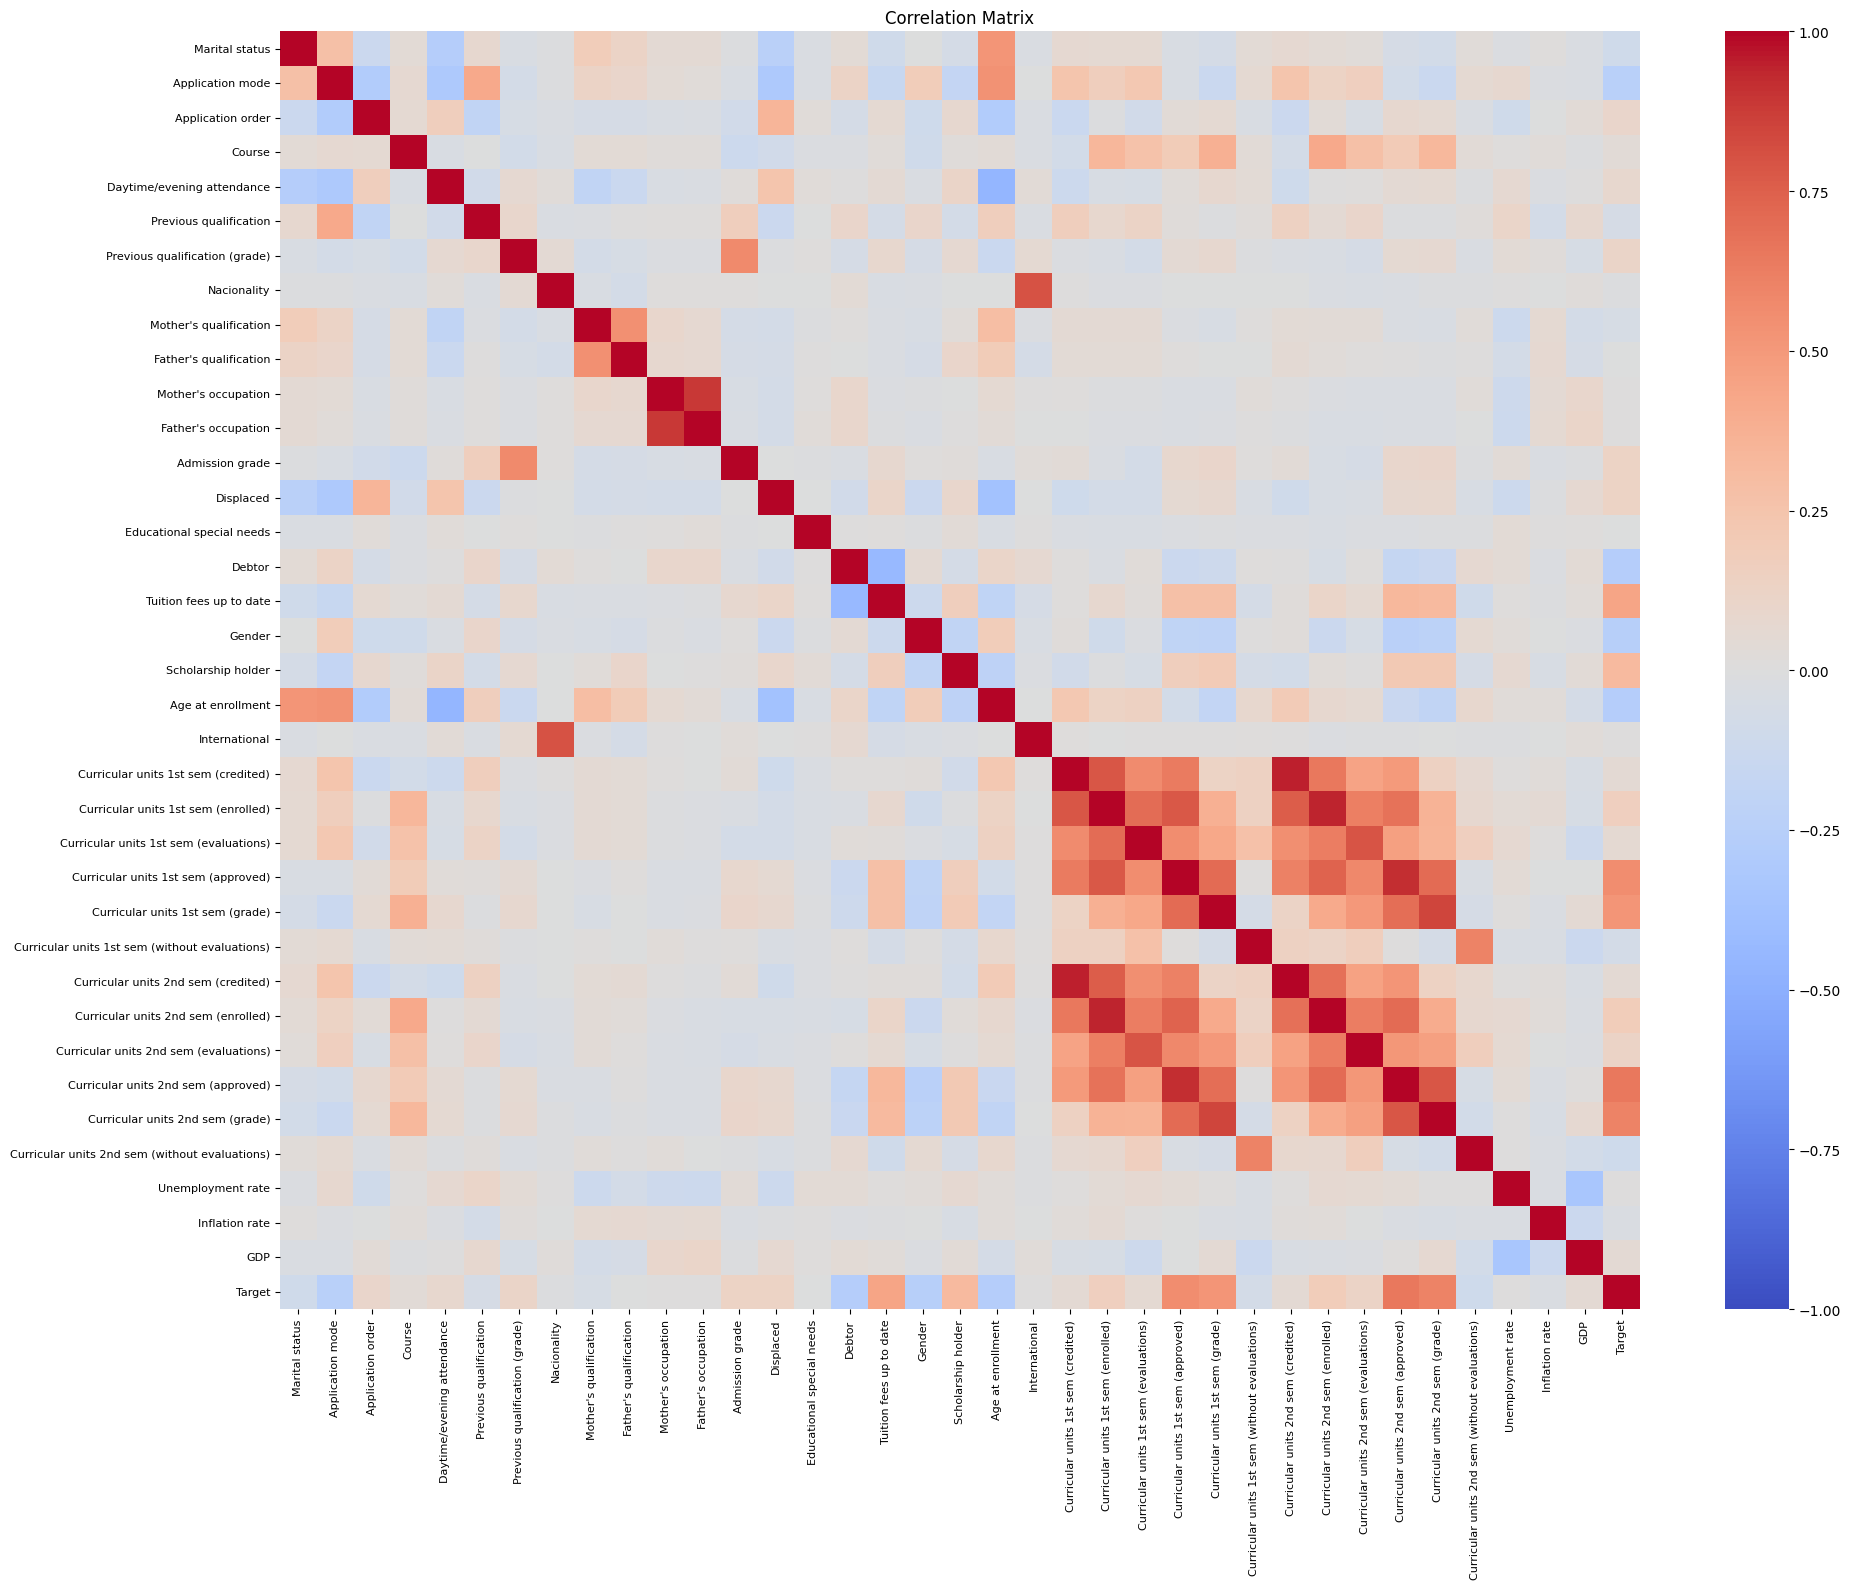

In [7]:
corr = df.drop(columns=['Graduated'], errors='ignore').corr(numeric_only=True)

plt.figure(figsize=(20, 16))

sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)

plt.title('Correlation Matrix')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

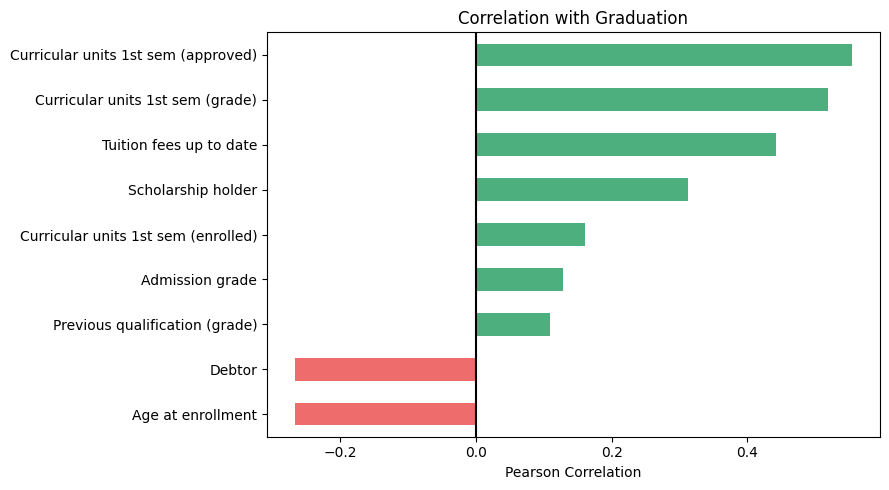

In [8]:
cols = [
    'Age at enrollment',
    'Admission grade',
    'Previous qualification (grade)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (enrolled)',
    'Scholarship holder',
    'Tuition fees up to date',
    'Debtor'
]

c = corr.loc[cols, 'Target'].sort_values()

plt.figure(figsize=(9, 5))
c.plot.barh(color=['#ef6c6c' if x < 0 else '#4caf7d' for x in c])

plt.axvline(0, color='black')
plt.title('Correlation with Graduation')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

## MODULE 2

In [9]:
df = df.drop(columns=['Graduated'], errors='ignore')
df = df.drop(columns=df.filter(like='Curricular units 2nd sem').columns)

X = df.drop('Target', axis=1)
y = df['Target']

print(X.shape, y.shape)

(3630, 30) (3630,)


In [10]:
numerical = [
    'Application order',
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

numerical += [c for c in X.columns if 'Curricular units 1st sem' in c]

binary = [
    'Daytime/evening attendance',
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International'
]

categorical = [c for c in X.columns if c not in numerical + binary]

print("Numerical:", len(numerical))
print("Binary:", len(binary))
print("Categorical:", len(categorical))

Numerical: 13
Binary: 8
Categorical: 9


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (2904, 30)
Testing: (726, 30)


In [12]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical)
], remainder='passthrough').set_output(transform='pandas')

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(2904, 220)
(726, 220)


## MODULE 3 

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=1)
}

params = {
    'Logistic Regression': {'model__C': [0.1, 1, 10]},
    'Decision Tree': {'model__max_depth': [3, 5, 10]},
    'KNN': {'model__n_neighbors': [5, 11, 21]},
    'Random Forest': {'model__n_estimators': [100, 200], 'model__max_depth': [None, 10]},
    'XGBoost': {'model__n_estimators': [100, 200], 'model__max_depth': [3, 5],
                'model__learning_rate': [0.05, 0.1]}
}

In [14]:
best_models, cv_scores = {}, {}

for name, model in models.items():
    pipe = Pipeline([('preprocessing', preprocessor), ('model', model)])
    grid = GridSearchCV(pipe, params[name], cv=5, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    cv_scores[name] = {'CV ROC-AUC': grid.best_score_, 'Best parameters': grid.best_params_}

pd.DataFrame(cv_scores).T.sort_values('CV ROC-AUC', ascending=False)

,CV ROC-AUC,Best parameters
XGBoost,0.935072,"{'model__learning_rate': 0.1, 'model__max_dept..."
Logistic Regression,0.934843,{'model__C': 1}
Random Forest,0.930275,"{'model__max_depth': None, 'model__n_estimator..."
Decision Tree,0.892444,{'model__max_depth': 5}
KNN,0.8775,{'model__n_neighbors': 21}


## MODULE 4

In [15]:
from sklearn.metrics import (roc_auc_score, precision_score, recall_score,
                             f1_score, average_precision_score)

scores = {}
for name, model in best_models.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 0]
    scores[name] = {
        'ROC-AUC': roc_auc_score(y_test == 0, prob),
        'Precision': precision_score(y_test, pred, pos_label=0),
        'Recall': recall_score(y_test, pred, pos_label=0),
        'F1': f1_score(y_test, pred, pos_label=0),
        'PR-AUC (AP)': average_precision_score(y_test == 0, prob)
    }

evaluation = pd.DataFrame(scores).T.sort_values('F1', ascending=False)
evaluation.round(4)

,ROC-AUC,Precision,Recall,F1,PR-AUC (AP)
XGBoost,0.9404,0.9390,0.8134,0.8717,0.9378
Logistic Regression,0.9406,0.9094,0.8134,0.8587,0.9338
Random Forest,0.9394,0.9095,0.7782,0.8387,0.9318
Decision Tree,0.9038,0.8943,0.7746,0.8302,0.8826
KNN,0.8762,0.9295,0.5106,0.6591,0.8410


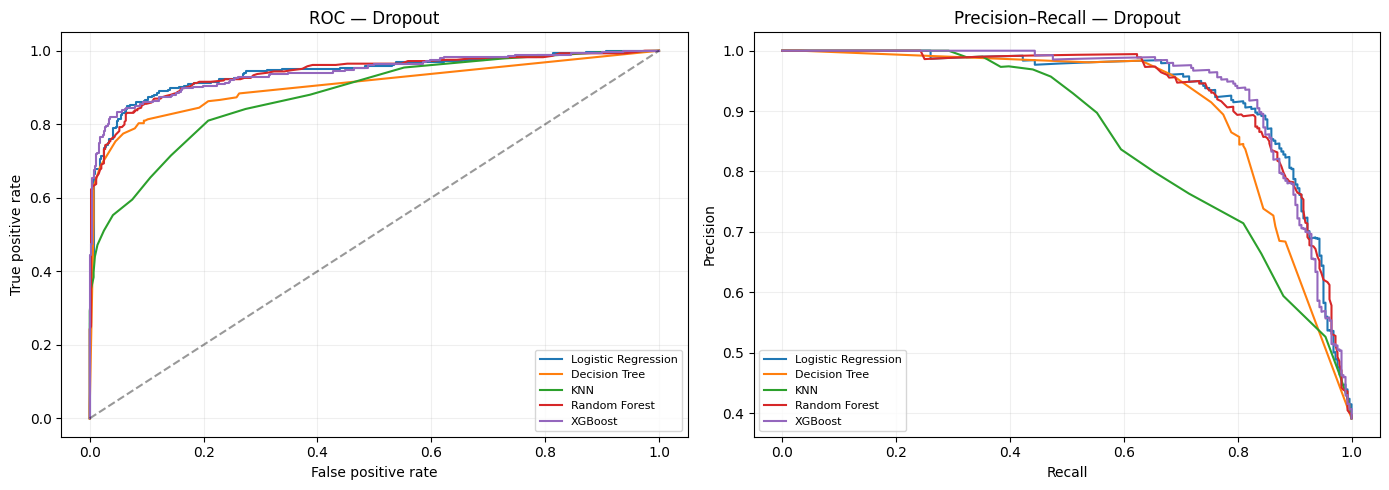

In [16]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for name, model in best_models.items():
    prob = model.predict_proba(X_test)[:, 0]
    fpr, tpr, _ = roc_curve(y_test == 0, prob)
    precision, recall, _ = precision_recall_curve(y_test == 0, prob)
    ax[0].plot(fpr, tpr, label=name)
    ax[1].plot(recall, precision, label=name)

ax[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax[0].set(xlabel='False positive rate', ylabel='True positive rate', title='ROC — Dropout')
ax[1].set(xlabel='Recall', ylabel='Precision', title='Precision–Recall — Dropout')
for a in ax:
    a.legend(fontsize=8)
    a.grid(alpha=0.2)
plt.tight_layout()
plt.show()

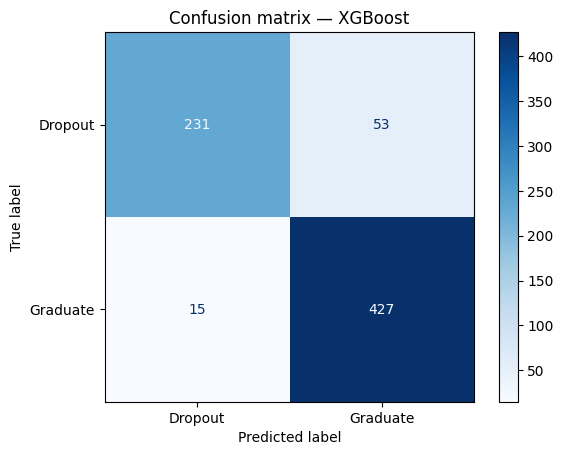

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

chosen = max(cv_scores, key=lambda x: cv_scores[x]['CV ROC-AUC'])
ConfusionMatrixDisplay.from_estimator(best_models[chosen], X_test, y_test,
    labels=[0, 1], display_labels=['Dropout', 'Graduate'], cmap='Blues')
plt.title(f'Confusion matrix — {chosen}')
plt.show()

In [18]:
from sklearn.model_selection import cross_val_predict
from ipywidgets import interact

prob_cv = cross_val_predict(best_models[chosen], X_train, y_train,
                            cv=3, method='predict_proba')[:, 0]

def threshold(t=0.5):
    pred = np.where(prob_cv >= t, 0, 1)
    p = precision_score(y_train, pred, pos_label=0, zero_division=0)
    r = recall_score(y_train, pred, pos_label=0)
    print(f'Dropout precision: {p:.3f} | Dropout recall: {r:.3f}')

interact(threshold, t=(0.1, 0.9, 0.05));

interactive(children=(FloatSlider(value=0.5, description='t', max=0.9, min=0.1, step=0.05), Output()), _dom_cl…

In [19]:
import joblib

model = best_models['XGBoost']

joblib.dump(model, '/kaggle/working/model.pkl')
joblib.dump(X.columns.tolist(), '/kaggle/working/features.pkl')

['/kaggle/working/features.pkl']

In [20]:
X.to_csv('/kaggle/working/reference.csv', index=False)